# MATH 210 Introduction to Mathematical Computing

**March 27, 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

## NumPy Arrays

NumPy arrays have several attributes:

* ndim - number of dimensions
* shape - number of entries in each dimension
* dtype - datatype

In [2]:
A = np.array([[1,2],[3,4],[5,6]])
print(A)

[[1 2]
 [3 4]
 [5 6]]


In [3]:
A.ndim

2

In [4]:
v = np.array([1,2,3,4,5])
print(v)

[1 2 3 4 5]


In [5]:
v.ndim

1

In [6]:
A.shape

(3, 2)

In [7]:
v.shape

(5,)

In [8]:
c1 = A[:,1]
c1

array([2, 4, 6])

In [9]:
c1.ndim

1

In [10]:
C1 = c1.reshape(3,1)
C1

array([[2],
       [4],
       [6]])

In [11]:
C1.ndim

2

In [12]:
C1.shape

(3, 1)

In [13]:
r0 = A[0,:]
r0

array([1, 2])

In [14]:
r0.ndim

1

In [15]:
A.dtype

dtype('int64')

In [16]:
A = np.array([[1.,2.],[3.,4.],[5.,6.]])
A

array([[1., 2.],
       [3., 4.],
       [5., 6.]])

In [17]:
A.dtype

dtype('float64')

## Solving Systems

In [18]:
N = 3
A = -2*np.eye(N) + np.diag(np.ones(N-1),1) + np.diag(np.ones(N-1),-1)
A

array([[-2.,  1.,  0.],
       [ 1., -2.,  1.],
       [ 0.,  1., -2.]])

In [19]:
b = np.array([3.,4.,2.])
b

array([3., 4., 2.])

In [20]:
x = la.solve(A,b)
x

array([-4.75, -6.5 , -4.25])

In [21]:
b1 = b.reshape(3,1)
b1

array([[3.],
       [4.],
       [2.]])

In [22]:
x1 = la.solve(A,b1)
x1

array([[-4.75],
       [-6.5 ],
       [-4.25]])

## Interpolation

Consider $N+1$ points: $(x_0,y_0),(x_1,y_1), \dots, (x_N,y_N)$ (where $x_i \ne x_j$ for $i \ne j$). An **interpolant** for the data is a function $f(x)$ such that $f(x_i) = y_i$ for all $i$. In other words, the graph of $y = f(x)$ passes through all the points.

Choose $f(x)$ to be a polynomial of degree $N$:

$$
f(x) = c_0 + c_1 x + \dots + c_N x^N
$$

We want to find coefficients $c_0,\dots,c_N$ such that $f(x)$ interpolates the data. This **polynomial interpolation**.

Each point gives an equation:

\begin{align*}
c_0 + c_1x_0 + \cdots + c_Nx_0^N &= y_0 \\
c_0 + c_1x_1 + \cdots + c_Nx_1^N &= y_1 \\
\vdots & \\
c_0 + c_1x_N + \cdots + c_Nx_N^N &= y_N
\end{align*}

Write this in matrix form:

$$
\begin{bmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^N \\
1 & x_1 & x_1^2 & \cdots & x_1^N \\
 \vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_N & x_N^2 & \cdots & x_N^N
\end{bmatrix}
\begin{bmatrix} c_0 \\ c_1 \\ \vdots \\ c_N \end{bmatrix}
= \begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_N \end{bmatrix}
$$

This is in the form $A \mathbf{c} = \mathbf{y}$ where $A$ is called the Vandermonde matrix. Turns out $\det(A) \ne 0$ and there is a unique solution.

In [23]:
x = np.array([-1.,0.,1.])
y = np.array([0.,1.,0.])
A = np.vander(x,increasing=True)
# A = np.column_stack([x**0,x**1,x**2])
A

array([[ 1., -1.,  1.],
       [ 1.,  0.,  0.],
       [ 1.,  1.,  1.]])

In [24]:
c = la.solve(A,y)
c

array([ 1.,  0., -1.])

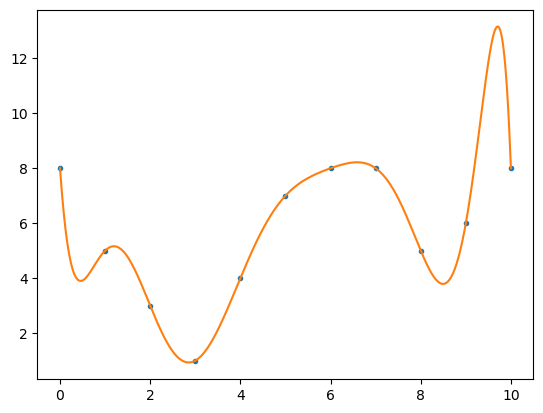

In [25]:
N = 10
x = np.arange(N+1)
y = np.random.randint(0,10,N+1)
A = np.vander(x,increasing=True)
c = la.solve(A,y)
xs = np.linspace(0,N,500)
ys = sum([c[n]*xs**n for n in range(N+1)])
plt.plot(x,y,'.',xs,ys)
plt.show()

In [26]:
c

array([ 8.00000000e+00, -2.32472222e+01,  4.52895040e+01, -3.65612213e+01,
        1.37247382e+01, -2.25271991e+00, -4.71064840e-03,  6.05324074e-02,
       -9.51554233e-03,  6.31062610e-04, -1.59832452e-05])